In [30]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [31]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

In [32]:
import os

os.listdir()

['.config', 'drive', 'sample_data']

In [33]:
import os

os.listdir('/content/drive/MyDrive')

['quantumlibrary.zip',
 'Classroom',
 '1.gdoc',
 '2.gdoc',
 'Colab Notebooks',
 'ml_sales_forecasting',
 'heart_disease_ml']

In [34]:
import os

os.listdir('/content/drive/MyDrive/ml_sales_forecasting')

['test.csv', 'features.csv', 'train.csv', 'stores.csv']

In [35]:
import pandas as pd

path = "/content/drive/MyDrive/ml_sales_forecasting/"

train = pd.read_csv(path + "train.csv")
test = pd.read_csv(path + "test.csv")
features = pd.read_csv(path + "features.csv")
stores = pd.read_csv(path + "stores.csv")

In [36]:
train.head()

,Store,Dept,Date,Weekly_Sales,IsHoliday
0,1,1,2010-02-05,24924.50,False
1,1,1,2010-02-12,46039.49,True
2,1,1,2010-02-19,41595.55,False
3,1,1,2010-02-26,19403.54,False
4,1,1,2010-03-05,21827.90,False


In [37]:
train.shape

(421570, 5)

In [38]:
train.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 421570 entries, 0 to 421569
Data columns (total 5 columns):
 #   Column        Non-Null Count   Dtype  
---  ------        --------------   -----  
 0   Store         421570 non-null  int64  
 1   Dept          421570 non-null  int64  
 2   Date          421570 non-null  object 
 3   Weekly_Sales  421570 non-null  float64
 4   IsHoliday     421570 non-null  bool   
dtypes: bool(1), float64(1), int64(2), object(1)
memory usage: 13.3+ MB


In [66]:
# Combine sales data with external features using common identifiers.
# Left join is used to keep all historical sales records.

df = train.merge(
    features,
    on=["Store", "Date", "IsHoliday"],
    how="left"
)

df = df.merge(
    stores,
    on="Store",
    how="left"
)

In [67]:
df.head()

,Store,Dept,Date,Weekly_Sales,IsHoliday,Temperature,Fuel_Price,MarkDown1,MarkDown2,MarkDown3,MarkDown4,MarkDown5,CPI,Unemployment,Type,Size
0,1,1,2010-02-05,24924.50,False,42.31,2.572,NaN,NaN,NaN,NaN,NaN,211.096358,8.106,A,151315
1,1,1,2010-02-12,46039.49,True,38.51,2.548,NaN,NaN,NaN,NaN,NaN,211.242170,8.106,A,151315
2,1,1,2010-02-19,41595.55,False,39.93,2.514,NaN,NaN,NaN,NaN,NaN,211.289143,8.106,A,151315
3,1,1,2010-02-26,19403.54,False,46.63,2.561,NaN,NaN,NaN,NaN,NaN,211.319643,8.106,A,151315
4,1,1,2010-03-05,21827.90,False,46.50,2.625,NaN,NaN,NaN,NaN,NaN,211.350143,8.106,A,151315


In [68]:
df.shape

(421570, 16)

In [69]:
df.columns

Index(['Store', 'Dept', 'Date', 'Weekly_Sales', 'IsHoliday', 'Temperature',
       'Fuel_Price', 'MarkDown1', 'MarkDown2', 'MarkDown3', 'MarkDown4',
       'MarkDown5', 'CPI', 'Unemployment', 'Type', 'Size'],
      dtype='object')

In [70]:
df.isnull().sum()

,0
Store,0
Dept,0
Date,0
Weekly_Sales,0
IsHoliday,0
Temperature,0
Fuel_Price,0
MarkDown1,270889
MarkDown2,310322
MarkDown3,284479


In [71]:
df["Date"] = pd.to_datetime(df["Date"])

In [72]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 421570 entries, 0 to 421569
Data columns (total 16 columns):
 #   Column        Non-Null Count   Dtype         
---  ------        --------------   -----         
 0   Store         421570 non-null  int64         
 1   Dept          421570 non-null  int64         
 2   Date          421570 non-null  datetime64[ns]
 3   Weekly_Sales  421570 non-null  float64       
 4   IsHoliday     421570 non-null  bool          
 5   Temperature   421570 non-null  float64       
 6   Fuel_Price    421570 non-null  float64       
 7   MarkDown1     150681 non-null  float64       
 8   MarkDown2     111248 non-null  float64       
 9   MarkDown3     137091 non-null  float64       
 10  MarkDown4     134967 non-null  float64       
 11  MarkDown5     151432 non-null  float64       
 12  CPI           421570 non-null  float64       
 13  Unemployment  421570 non-null  float64       
 14  Type          421570 non-null  object        
 15  Size          421

In [73]:
# Extract time-based features from Date to help the model
# capture seasonal patterns in sales.

df["Year"] = df["Date"].dt.year
df["Month"] = df["Date"].dt.month
df["Week"] = df["Date"].dt.isocalendar().week.astype(int)

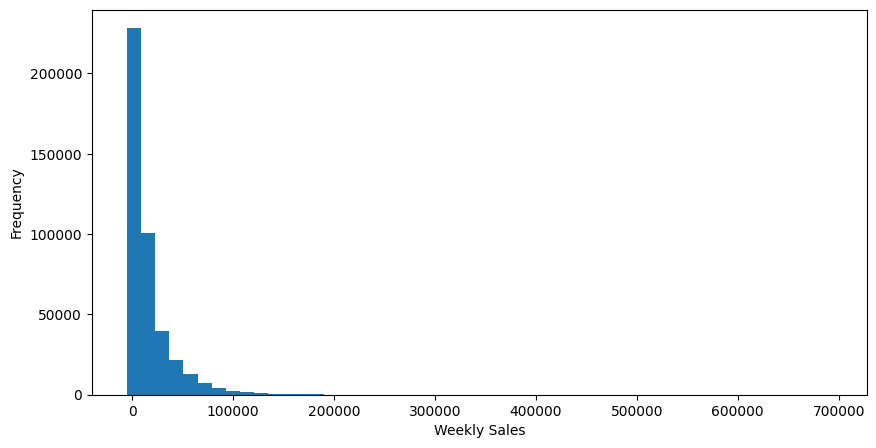

In [74]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10,5))
plt.hist(df["Weekly_Sales"], bins=50)
plt.xlabel("Weekly Sales")
plt.ylabel("Frequency")
plt.show()

In [75]:
df.columns

Index(['Store', 'Dept', 'Date', 'Weekly_Sales', 'IsHoliday', 'Temperature',
       'Fuel_Price', 'MarkDown1', 'MarkDown2', 'MarkDown3', 'MarkDown4',
       'MarkDown5', 'CPI', 'Unemployment', 'Type', 'Size', 'Year', 'Month',
       'Week'],
      dtype='object')

In [76]:
# Markdown columns contain missing values because promotional markdowns
# were not available for every week.
# Missing values are replaced with 0 because no markdown activity
# is treated as absence of promotion.

df.isnull().sum()

,0
Store,0
Dept,0
Date,0
Weekly_Sales,0
IsHoliday,0
Temperature,0
Fuel_Price,0
MarkDown1,270889
MarkDown2,310322
MarkDown3,284479


In [77]:
df.head()

,Store,Dept,Date,Weekly_Sales,IsHoliday,Temperature,Fuel_Price,MarkDown1,MarkDown2,MarkDown3,MarkDown4,MarkDown5,CPI,Unemployment,Type,Size,Year,Month,Week
0,1,1,2010-02-05,24924.50,False,42.31,2.572,NaN,NaN,NaN,NaN,NaN,211.096358,8.106,A,151315,2010,2,5
1,1,1,2010-02-12,46039.49,True,38.51,2.548,NaN,NaN,NaN,NaN,NaN,211.242170,8.106,A,151315,2010,2,6
2,1,1,2010-02-19,41595.55,False,39.93,2.514,NaN,NaN,NaN,NaN,NaN,211.289143,8.106,A,151315,2010,2,7
3,1,1,2010-02-26,19403.54,False,46.63,2.561,NaN,NaN,NaN,NaN,NaN,211.319643,8.106,A,151315,2010,2,8
4,1,1,2010-03-05,21827.90,False,46.50,2.625,NaN,NaN,NaN,NaN,NaN,211.350143,8.106,A,151315,2010,3,9


In [78]:
markdown_cols = [
    "MarkDown1",
    "MarkDown2",
    "MarkDown3",
    "MarkDown4",
    "MarkDown5"
]

df[markdown_cols] = df[markdown_cols].fillna(0)

In [79]:
df.isnull().sum()

,0
Store,0
Dept,0
Date,0
Weekly_Sales,0
IsHoliday,0
Temperature,0
Fuel_Price,0
MarkDown1,0
MarkDown2,0
MarkDown3,0


In [80]:
df = df.drop("Date", axis=1)

In [81]:
# Convert categorical store type values into numerical features
# because machine learning models require numerical input.

df = pd.get_dummies(
    df,
    columns=["Type"],

    # Drop the first category to avoid redundant dummy variables.

    drop_first=True
)

In [82]:
df.head()

,Store,Dept,Weekly_Sales,IsHoliday,Temperature,Fuel_Price,MarkDown1,MarkDown2,MarkDown3,MarkDown4,MarkDown5,CPI,Unemployment,Size,Year,Month,Week,Type_B,Type_C
0,1,1,24924.50,False,42.31,2.572,0.0,0.0,0.0,0.0,0.0,211.096358,8.106,151315,2010,2,5,False,False
1,1,1,46039.49,True,38.51,2.548,0.0,0.0,0.0,0.0,0.0,211.242170,8.106,151315,2010,2,6,False,False
2,1,1,41595.55,False,39.93,2.514,0.0,0.0,0.0,0.0,0.0,211.289143,8.106,151315,2010,2,7,False,False
3,1,1,19403.54,False,46.63,2.561,0.0,0.0,0.0,0.0,0.0,211.319643,8.106,151315,2010,2,8,False,False
4,1,1,21827.90,False,46.50,2.625,0.0,0.0,0.0,0.0,0.0,211.350143,8.106,151315,2010,3,9,False,False


In [83]:
df.shape

(421570, 19)

In [84]:
X = df.drop("Weekly_Sales", axis=1)
y = df["Weekly_Sales"]

In [85]:
df["Year"].value_counts()

,count
Year,
2011,153453
2010,140679
2012,127438


In [86]:
train_data = df[df["Year"] < 2012]
test_data = df[df["Year"] == 2012]

In [88]:
# Split data into training and testing sets to evaluate
# model performance on unseen data.

X_train = train_data.drop("Weekly_Sales", axis=1)
y_train = train_data["Weekly_Sales"]

X_test = test_data.drop("Weekly_Sales", axis=1)
y_test = test_data["Weekly_Sales"]

In [89]:
# Random Forest is used because it can capture nonlinear relationships
# between sales and multiple features.
# n_jobs=-1 enables parallel processing using all available CPU cores.

from sklearn.ensemble import RandomForestRegressor

model = RandomForestRegressor(
    n_estimators=100,
    random_state=42,
    n_jobs=-1
)

In [90]:
model.fit(X_train, y_train)

RandomForestRegressor(n_jobs=-1, random_state=42)

In [91]:
y_pred = model.predict(X_test)

In [92]:
# Evaluate model performance using MAE and RMSE.
# Lower values indicate better forecasting accuracy.

from sklearn.metrics import mean_absolute_error, mean_squared_error
import numpy as np

mae = mean_absolute_error(y_test, y_pred)

rmse = np.sqrt(
    mean_squared_error(y_test, y_pred)
)

print("MAE:", mae)
print("RMSE:", rmse)

MAE: 2285.1984083468037
RMSE: 5022.626682645403


In [93]:
importance = pd.DataFrame({
    "Feature": X_train.columns,
    "Importance": model.feature_importances_
})

importance = importance.sort_values(
    by="Importance",
    ascending=False
)

importance.head(10)

,Feature,Importance
1,Dept,0.614349
12,Size,0.190123
0,Store,0.049358
15,Week,0.047128
10,CPI,0.031929
11,Unemployment,0.015099
3,Temperature,0.012074
16,Type_B,0.010925
7,MarkDown3,0.008577
14,Month,0.007330


In [94]:
!pip install xgboost

In [95]:
from xgboost import XGBRegressor

xgb_model = XGBRegressor(
    n_estimators=500,
    learning_rate=0.05,
    max_depth=8,
    random_state=42
)

In [96]:
xgb_model.fit(X_train, y_train)

XGBRegressor(base_score=None, booster=None, callbacks=None,
             colsample_bylevel=None, colsample_bynode=None,
             colsample_bytree=None, device=None, early_stopping_rounds=None,
             enable_categorical=True, eval_metric=None, feature_types=None,
             feature_weights=None, gamma=None, grow_policy=None,
             importance_type=None, interaction_constraints=None,
             learning_rate=0.05, max_bin=None, max_cat_threshold=None,
             max_cat_to_onehot=None, max_delta_step=None, max_depth=8,
             max_leaves=None, min_child_weight=None, missing=nan,
             monotone_constraints=None, multi_strategy=None, n_estimators=500,
             n_jobs=None, num_parallel_tree=None, ...)

In [97]:
xgb_pred = xgb_model.predict(X_test)

In [98]:
mae = mean_absolute_error(y_test, xgb_pred)

rmse = np.sqrt(
    mean_squared_error(y_test, xgb_pred)
)

print("MAE:", mae)
print("RMSE:", rmse)

MAE: 2675.153675823668
RMSE: 4701.246732923319


In [99]:
# Analyze which features contribute the most to the model predictions.

importance = pd.DataFrame({
    "Feature": X_train.columns,
    "Importance": model.feature_importances_
})

importance = importance.sort_values(
    by="Importance",
    ascending=False
)

importance.head(15)

,Feature,Importance
1,Dept,0.614349
12,Size,0.190123
0,Store,0.049358
15,Week,0.047128
10,CPI,0.031929
11,Unemployment,0.015099
3,Temperature,0.012074
16,Type_B,0.010925
7,MarkDown3,0.008577
14,Month,0.007330


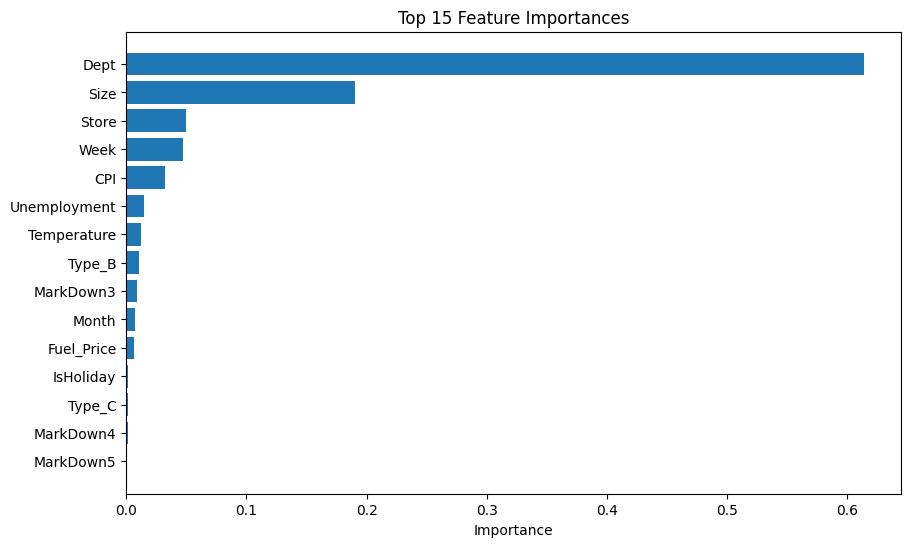

In [100]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10,6))

plt.barh(
    importance["Feature"].head(15),
    importance["Importance"].head(15)
)

plt.gca().invert_yaxis()

plt.xlabel("Importance")
plt.title("Top 15 Feature Importances")

plt.show()

In [103]:
df.columns

Index(['Store', 'Dept', 'Weekly_Sales', 'IsHoliday', 'Temperature',
       'Fuel_Price', 'MarkDown1', 'MarkDown2', 'MarkDown3', 'MarkDown4',
       'MarkDown5', 'CPI', 'Unemployment', 'Size', 'Year', 'Month', 'Week',
       'Type_B', 'Type_C'],
      dtype='object')

In [104]:
df_lag = train.merge(
    features,
    on=["Store", "Date", "IsHoliday"],
    how="left"
)

df_lag = df_lag.merge(
    stores,
    on="Store",
    how="left"
)

In [105]:
df_lag["Date"] = pd.to_datetime(df_lag["Date"])

In [106]:
# Sort data chronologically because lag features depend on previous time periods.

df_lag = df_lag.sort_values(
    ["Store", "Dept", "Date"]
)

In [107]:
# Create a lag feature representing previous week's sales.
# Previous sales often provide strong information for future forecasting.

df_lag["Sales_lag_1"] = (
    df_lag
    .groupby(["Store", "Dept"])["Weekly_Sales"]
    .shift(1)
)

In [108]:
# Create a 4-week lag feature to capture longer-term sales patterns.

df_lag["Sales_lag_4"] = (
    df_lag
    .groupby(["Store", "Dept"])["Weekly_Sales"]
    .shift(4)
)

In [109]:
# Calculate the average sales of the previous 4 weeks
# to capture recent sales trends while reducing noise.

df_lag["Sales_rolling_4"] = (
    df_lag
    .groupby(["Store", "Dept"])["Weekly_Sales"]
    .shift(1)
    .rolling(4)
    .mean()
)

In [110]:
df_lag[
    [
        "Store",
        "Dept",
        "Date",
        "Weekly_Sales",
        "Sales_lag_1",
        "Sales_lag_4",
        "Sales_rolling_4"
    ]
].head(10)

,Store,Dept,Date,Weekly_Sales,Sales_lag_1,Sales_lag_4,Sales_rolling_4
0,1,1,2010-02-05,24924.50,NaN,NaN,NaN
1,1,1,2010-02-12,46039.49,24924.50,NaN,NaN
2,1,1,2010-02-19,41595.55,46039.49,NaN,NaN
3,1,1,2010-02-26,19403.54,41595.55,NaN,NaN
4,1,1,2010-03-05,21827.90,19403.54,24924.50,32990.7700
5,1,1,2010-03-12,21043.39,21827.90,46039.49,32216.6200
6,1,1,2010-03-19,22136.64,21043.39,41595.55,25967.5950
7,1,1,2010-03-26,26229.21,22136.64,19403.54,21102.8675
8,1,1,2010-04-02,57258.43,26229.21,21827.90,22809.2850
9,1,1,2010-04-09,42960.91,57258.43,21043.39,31666.9175


In [111]:
markdown_cols = [
    "MarkDown1",
    "MarkDown2",
    "MarkDown3",
    "MarkDown4",
    "MarkDown5"
]

df_lag[markdown_cols] = df_lag[markdown_cols].fillna(0)

In [112]:
df_lag["Year"] = df_lag["Date"].dt.year
df_lag["Month"] = df_lag["Date"].dt.month
df_lag["Week"] = df_lag["Date"].dt.isocalendar().week.astype(int)

In [113]:
df_lag = df_lag.drop("Date", axis=1)

In [114]:
df_lag = pd.get_dummies(
    df_lag,
    columns=["Type"],
    drop_first=True
)

In [123]:
df_lag = df_lag.dropna()

In [124]:
train_data = df_lag[df_lag["Year"] < 2012]
test_data = df_lag[df_lag["Year"] == 2012]

X_train = train_data.drop("Weekly_Sales", axis=1)
y_train = train_data["Weekly_Sales"]

X_test = test_data.drop("Weekly_Sales", axis=1)
y_test = test_data["Weekly_Sales"]

In [120]:
from sklearn.ensemble import RandomForestRegressor

lag_model = RandomForestRegressor(
    n_estimators=100,
    random_state=42,
    n_jobs=-1
)

lag_model.fit(X_train, y_train)

RandomForestRegressor(n_jobs=-1, random_state=42)

In [125]:
lag_pred = lag_model.predict(X_test)

In [126]:
from sklearn.metrics import mean_absolute_error, mean_squared_error
import numpy as np

print("MAE:", mean_absolute_error(y_test, lag_pred))

print(
    "RMSE:",
    np.sqrt(mean_squared_error(y_test, lag_pred))
)

MAE: 1580.1425349209715
RMSE: 3368.6412191917943


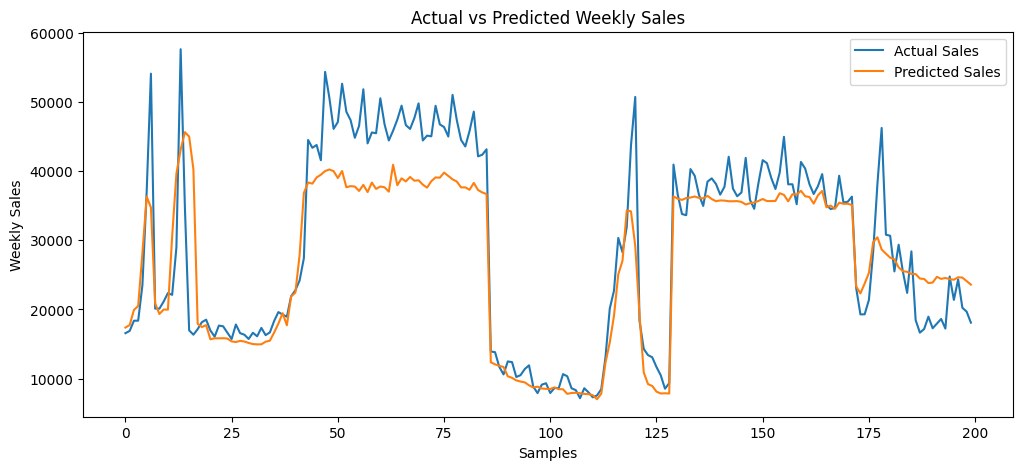

In [127]:
import matplotlib.pyplot as plt

plt.figure(figsize=(12,5))

plt.plot(
    y_test.values[:200],
    label="Actual Sales"
)

plt.plot(
    y_pred[:200],
    label="Predicted Sales"
)

plt.title("Actual vs Predicted Weekly Sales")
plt.xlabel("Samples")
plt.ylabel("Weekly Sales")
plt.legend()
plt.show()

In [ ]:
importance_lag = pd.DataFrame({
    "Feature": X_train.columns,
    "Importance": lag_model.feature_importances_
})

importance_lag = importance_lag.sort_values(
    "Importance",
    ascending=False
)

importance_lag.head(15)

,Feature,Importance
13,Sales_lag_1,0.739176
15,Sales_rolling_4,0.186955
14,Sales_lag_4,0.025277
18,Week,0.012444
1,Dept,0.007890
7,MarkDown3,0.005640
3,Temperature,0.003429
11,Unemployment,0.003024
10,CPI,0.002445
4,Fuel_Price,0.002424


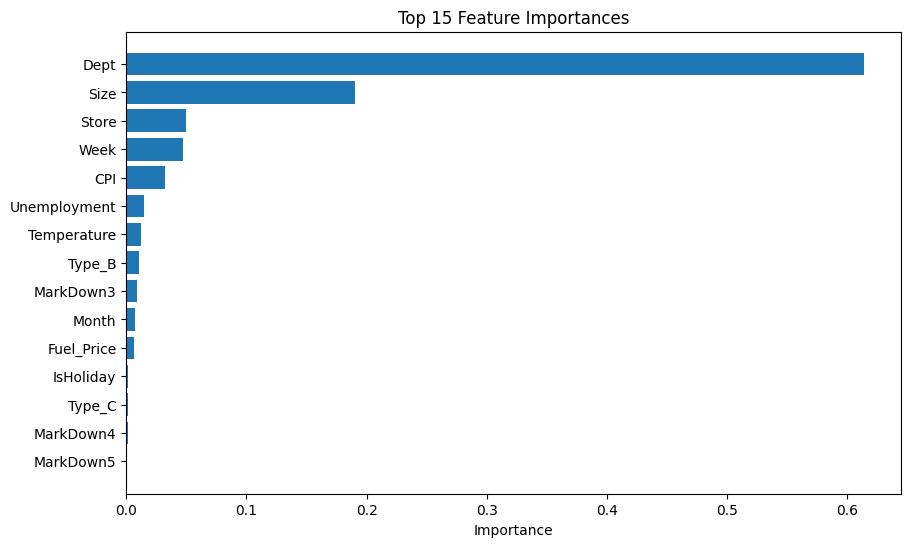

In [128]:
plt.figure(figsize=(10,6))

top_features = importance.head(15)

plt.barh(
    top_features["Feature"],
    top_features["Importance"]
)

plt.title("Top 15 Feature Importances")
plt.xlabel("Importance")

plt.gca().invert_yaxis()

plt.show()

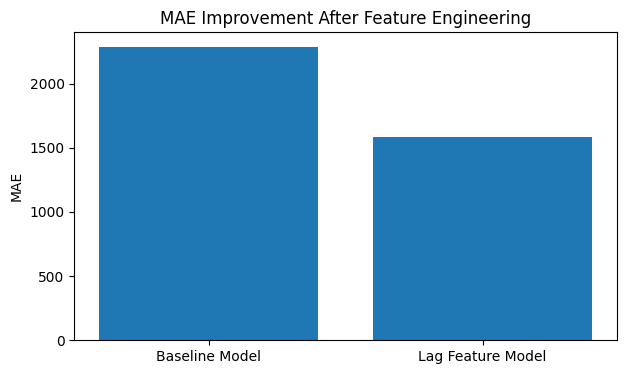

In [129]:
models = [
    "Baseline Model",
    "Lag Feature Model"
]

mae_scores = [
    2285.19,
    1580.14
]

plt.figure(figsize=(7,4))

plt.bar(
    models,
    mae_scores
)

plt.title("MAE Improvement After Feature Engineering")
plt.ylabel("MAE")

plt.show()

In [132]:
import joblib

joblib.dump(
    lag_model,
    "sales_forecasting_model.pkl"
)

['sales_forecasting_model.pkl']

In [133]:
!pip freeze | grep -E "pandas|numpy|scikit|sklearn|xgboost|matplotlib" > requirements.txt